In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Advanced Applied Econometrics

# Dynamic labor supply - A simple life-cycle framework

### Summer 2026

In order to understand the core principles of solving finite-horizon models like the one in KW97 via backward induction, this problem set asks you to solve a simplified setup with limited heterogeneity and a short time horizon.

**Single-agent framework:** We consider a single-agent life-cycle model of labor supply and consumption decisions, a stripped-down version of the Blundell et al. (2016) model, tracing out behavior from labor-market entry onwards. The goal is to illustrate the dynamic incentives shaping labor supply and consumption over a finite horizon.

**Time horizon and agent/worker:**
- Start with a small time horizon: three periods (e.g. years since labor-market entry), equivalent to using age. We index periods by $t=0,1,2$.
- Every period the worker (notation abstracts from the individual index $i$) maximizes lifetime utility (the baseline is deterministic; the expectation becomes relevant only once wage shocks are added in Problem 6) given current characteristics and the economic environment: age $t$, work experience $e_{t}$, and a two-dimensional unobserved work-disutility term $\theta = (\theta_{P}, \theta_{F})$ over part-time (P) and full-time (F) employment. We denote the vector of state variables at age $t$ by $X_t$.
- *Convention:* we order $\theta=(\theta_{P},\theta_{F})$; Blundell et al. (2016), eq. (1), use the reverse order $(\theta_{F},\theta_{P})$. Keep this in mind when cross-referencing the paper.

**Assumptions on utility:**
- Utility is *inter-temporally separable* (additively separable across periods $t$), but *within* a period it is *non-separable in consumption and leisure*. Instantaneous utility depends on current consumption $c_{t}$, labor supply $l_t$, and work preferences $\theta$. The worker's flow utility at age $t$ is (cf. Blundell et al. (2016), eq. (1)):

$$u(c_t, l_t; \theta) = \frac{c_t^\mu}{\mu}\, \exp\!\left[ U(l_t, \theta) \right]$$

- Labor supply $l_t$ is a discrete choice with three alternatives: out of work (O), part-time (P), and full-time (F). We use "out of work" / non-employment (the paper's $O$) rather than "unemployment", since no job search is modeled. The term $U(\cdot)$ shifts the marginal utility of consumption with the labor-supply choice and preferences $\theta$; it is normalized to $0$ out of work.
- $\mu<0$ is the curvature parameter governing risk aversion and the elasticity of intertemporal substitution. Because $\mu<0$, flow utility $c_t^\mu/\mu$ is **negative**, so a **positive** $U(\cdot)$ scales it by $\exp[U]>1$ and pushes utility *further* below zero. Hence working lowers the utility of consumption, $\theta_P,\theta_F>0$ are **disutilities** of work, and consumption and labor supply are complements (cf. Blundell et al. (2016), p.1734).
- With $\theta_F>\theta_P>0$, full-time work is more costly than part-time.

$$
U(l_t, \theta) =
\begin{cases}
0, & \text{if } l_t = O, \\[4pt]
\theta_P, & \text{if } l_t = P, \\[4pt]
\theta_F, & \text{if } l_t = F.
\end{cases}
$$

**Decision problem:**
At every age $t$, the worker chooses labor supply $l_t$ and consumption $c_t$ to maximize expected lifetime utility, given the current state $X_t$ and the future consequences of current choices:

$$V_t(X_t) = \max_{ \{ c_\tau, l_\tau \}_{\tau = t,\dots,T} } E \left[ \sum_{\tau = t}^{T} \beta^{\tau - t} u(c_\tau, l_\tau; \theta, X_{\tau}) \;\middle|\; X_t \right]
\qquad \text{s.t. the budget constraint.}$$

- The expectation $E[\cdot]$ is taken over future random events conditional on $X_t$; $\beta$ is the discount factor; $V_t$ is the optimal value of discounted present and future utility.
- Here consumption $c_t$ is pinned down by the labor-supply choice $l_t$ (see the budget constraint below), so the choice reduces to $l_t$.
- NOTE: this baseline setup contains no stochastic elements; it is purely deterministic.

**Budget constraint / available consumption:**
- For this problem set we abstract from the full tax-transfer system, assets, and savings in Blundell et al. (2016). Available consumption $c_{t}$ is therefore pinned down directly by current labor earnings.
- Earnings (and hence consumption) are measured **per period**, as a function of the per-period wage rate $w_{t}$ and a per-period hours choice $h_{t}\in\{0,24,38\}$ (corresponding to O, P, F). We deliberately leave time units abstract: all flows are per model period.

$$c_t = w_t\, h_t \qquad \text{for } l_t\in\{P,F\}.$$

- Out of work there are no earnings. To stand in for the transfer system (out-of-work benefits) and to keep flow utility well-defined for $\mu<0$ (where $c\to 0$ sends $c^\mu/\mu\to-\infty$), we impose a **consumption floor** $\bar c>0$ when out of work:

$$c_t = \bar c \qquad \text{for } l_t = O.$$

- This floor is the only deviation of the consumption side from the paper, forced by dropping assets and $T(\cdot)$; it plays the role of the income floor implied by income support in Blundell et al. (2016).

**Human capital and earnings dynamics:**
The worker's hourly wage $w_{t}$ is a deterministic function of accumulated work experience $e_t$ and a constant productivity intercept. The log-log specification gives curvature in the wage-experience profile, consistent with the empirical evidence.

Experience accumulation is a function of the previous period's labor-supply choice, $g(l_{t-1})$. In principle one normalizes full-time accumulation to $g(l_{t-1}=F)=1$ and estimates the relative value of part-time experience $g(l_{t-1}=P)$ from the data. For illustration we instead fix integer accumulation directly, $g(l_{t-1}=P)=1$ and $g(l_{t-1}=F)=2$, so that experience is always integer-valued and the state space stays small. This both inverts the paper's normalization ($g_s(F)=1$) and raises the *relative* part-time value to $g(P)/g(F)=0.5$, well above the paper's estimate of $0.10$-$0.15$; it is a purely computational device, so do not read structural meaning into these values (see the calibration note below).

$$
\begin{aligned}
\ln(w_{t}) &= \gamma_0 + \gamma_1 \ln(e_{t} + 1) \\
e_{t} &= e_{t-1} + g(l_{t-1}) \\
e_0 &= 0 \quad \text{(no work experience at labor-market entry)}
\end{aligned}
$$

**Calibration of the model:**
- $\mu = -0.5$, giving relative risk aversion $1-\mu = 1.5$ (the paper uses $\mu=-0.56$, i.e. RRA $=1.56$).
- $\beta = 0.98$ (as in the paper).
- Wage equation: intercept $\gamma_0 = 2$, experience slope $\gamma_1 = 0.2$.
- Experience accumulation: $g(l_{t-1}=P) = 1$, $g(l_{t-1}=F) = 2$ (integer device; see the note above on the inverted normalization and the inflated part-time ratio relative to the paper's $0.10$-$0.15$).
- Part-time hours $h_t=24$ (raised from $18$) so that part-time earnings clear the out-of-work floor $\bar c$ already at $e=0$ and part-time remains a relevant alternative at low experience; with $h_t=18$, part-time consumption at labor-market entry would fall below the floor and, combined with the disutility $\theta_P$, part-time would never be attractive early on.
- Disutility of work: $\theta_P = 0.1$, $\theta_F = 0.34$ (both **positive**, $\theta_F>\theta_P$, so work lowers utility and full-time costs more; consistent with the sign logic of $U(\cdot)$ above). $\theta_F$ is set close to the static full-time / non-employment indifference threshold so that the human-capital channel is pivotal: a myopic agent and a forward-looking agent need not make the same choice.
- Out-of-work consumption floor: $\bar c = 150$ (out-of-work-benefits stand-in).

## Problem 1: General questions:

**1.1** What are the structural parameters in wage and utility specification of this framework? Discuss their role in the model and how they influence behavior.

**Solution draft 1.1**:

- $\mu$ curvature parameter
- $\beta$: discount factor, applied to discount future utility flows in the dynamic optimization/decision problem
- $\gamma_0$: intercept of the wage equation
- $\gamma_1$: returns to log-experience; note that log-specification introduces a curvature in the experience profile with diminishing returns
- $g(l_{t-1})$: human-capital accumulation parameters governing how working part-time or full-time translates into (productivity-relevant) work experience. The substantive discussion is deferred to **1.2**, which asks about this process directly; here we simply note that $g(\cdot)$ is the link between the discrete labor-supply choice and next period's state. In an interesting application, Blesch et al. (2024) "Biased wage expectations and female labor supply" show that biased expectations about long-run wage-growth trajectories can have substantial effects on employment and welfare.
- $(\theta_P,\theta_F)$: dis-utility of work parameters


**1.2 Experience accumulation:** 
- Discuss the process governing the endogenous accumulation of human capital/work experience. What is captured by $g(l_{t-1})$?
- Review Blundell et al. (2016), p.1727f: How does their specification $e_{t} = e_{t-1} (1 - \delta) + g(l_{t-1})$ differ from this setup? What is the role of structural parameter $\delta$? What human capital/wage dynamics can be captured with this setup?

**Solution draft 1.2:**
- $\delta$: depreciation rate of work experience. If the worker is out-of-work their experience stock depreciates at rate $\delta$. Working counter-balances this depreciation, depending on the estimated accumulation parameters for part-time and full-time.
- Blundell et al. (2016), p1732, show there is a specific human-captial cost associated with being out-of-work, which they estimate using the (education-specific) depreciation rates to 5.7%-8.1%. One of their main insights in this regard is that since the estimated experience accumulation parameter in part-time is only a fraction of the full-time accumulation rate (15%), it barely counteracts the general depreciation rate. Working part-time thus results in almost no effective experience accumulation, leading to long-term flat wage-profiles.
- *Learning-by-doing*: endogenous, deterministic accumulation of work experience depending on labor supply choices. Adds dynamic incentives to labor supply choices in any given period (forward-looking investment into human capital).

**1.3 Budget constraint:** Review the more comprehensive budget constraint in Blundell et al. (2016), p.1726. Discuss the implications of the more comprehensive specification in the paper for worker's decision making. And more generally, how does the budget constraint differ from the static setting in terms of dynamic incentives?

**Solution draft 1.3:**

The paper's budget constraint holds assets and lets the worker save/borrow, whereas here consumption is pinned down mechanically by current earnings, $c_t = w_t h_t$ (or the floor $\bar c$).

*Implications of the richer specification:*
- **A second endogenous state (assets):** Savings/accumulated assets become an additional state variable alongside experience, and the worker now has an intertemporal *consumption-smoothing* margin that is entirely absent here.
- **Self-insurance and consumption smoothing via savings decisions** Relative to relying on the tax-transfer system alone, assets let the worker self-insure against wage/earnings fluctuations, smoothing consumption across periods and states.
- **Labor supply is no longer pinned down by current earnings.** Because consumption can be financed out of assets, the shortcut $c_t = w_t h_t$ breaks: labor supply and consumption become separate choices.
- Additional cost components relevant to the analysis goal of the model: **childcare costs Q(.)**.

*Dynamic incentives vs. the static setting more generally:*
- In the static problem, the labor-supply choice trades off current consumption against current disutility only.
- Two dynamic margins are added: (i) the **human-capital channel**: working today raises $e_{t+1}$ and hence future wages; and (ii) with assets, the **saving channel**: an Euler equation links marginal utility of consumption across periods, so today's choice depends on expected future returns and needs, independently of the experience channel.

## Problem 2: Static setting and implications of dynamic incentives

In [2]:
# Use a dictionary to store the parameters of the model
calib_params = {
    'mu': -0.5,
    'beta': 0.98,
    'theta_P': 0.1,
    'theta_F': 0.34, 
    'gamma_0': 2,
    'gamma_1': 0.2,
    'g_P': 1,
    'g_F': 2,
}
calib_params

{'mu': -0.5,
 'beta': 0.98,
 'theta_P': 0.1,
 'theta_F': 0.34,
 'gamma_0': 2,
 'gamma_1': 0.2,
 'g_P': 1,
 'g_F': 2}

In [3]:
# It is often useful to store information about the model specification in a separate dict
model_options = {
    'hours': np.array([0, 24, 38]),
    'num_choices': 3,
    'consumption_ue': 150, # out-of-work consumption floor (out-of-work-benefits stand-in)
    'num_periods': 3
}
model_options

{'hours': array([ 0, 24, 38]),
 'num_choices': 3,
 'consumption_ue': 150,
 'num_periods': 3}

**2.1** Assume again a static setting (or a myopic agent with $\beta=0$), where the worker only considers the first period $t=0$ in their labor supply decision. Write down and describe the decision-problem of the worker. What determines the optimal choice? 

- Period 0: experience stock is zero; 
- Derive utility for each choice alternative.

**Solution draft 2.1:**
- Myopic agent only considers current instanteous flow-utility in decision problem. Labor-supply choice is pinned down by experience-level and hours options. Note that since the model does not include a savings choice (and elaborate budget constraint), consumption is pinned down by the labor supply.
- Given the deterministic setup of the model we can drop the expectation operator.

$$V_0(X_0) = \max_{ \{ c_0, l_0 \} }  u(c_0, l_0; \theta, X_0) \qquad \text{s.t. the budget constraint.}$$

- To derive the optimal choice: compute the choice-specific flow-utility for each choice option and arg-max.

**2.2** Compute the utility of each choice alternative and the optimal labor supply choice for the worker in the first period $t=0$. 

In [4]:
# derive static utility 
def utility_function(hours_choice, exp_level, params, model_options):
    """Calculates the flow utility of a given choice dependent on the experience level.

    Args:
        hours_choice (int): The number of hours worked.
        exp_level (int): The experience level.
        params (dict): A dictionary with the parameterization for the model.
        model_options (dict): A dictionary with the model specification
            (hours grid, out-of-work consumption floor, etc.).

    Returns:
        utility (float): The flow utility of the choice.
    """

    hourly_wage = np.exp(params["gamma_0"] + params["gamma_1"] * np.log(exp_level + 1))

    if hours_choice == 0:
        consumption = model_options["consumption_ue"]
        theta = 0
    elif hours_choice == 24:
        consumption = hourly_wage * hours_choice
        theta = params["theta_P"]
    elif hours_choice == 38:
        consumption = hourly_wage * hours_choice
        theta = params["theta_F"]
    else:
        raise ValueError(f"Unsupported hours choice: {hours_choice}")

    return (consumption ** params["mu"]) / params["mu"] * np.exp(theta)

In [5]:
# derive utility for all choices in static setting
exp_level = 0  # no experience at labor market entry
choice_specific_utilities = np.zeros(model_options['num_choices']) 

# loop over choices:
for choice_option in range(model_options["num_choices"]):
    hours_choice = model_options["hours"][choice_option]
    utility = utility_function(hours_choice, exp_level, calib_params, model_options)
    choice_specific_utilities[choice_option] = utility
    print(f"Utility for {hours_choice} hours: {utility}")
print("Choice-specific utilities:", choice_specific_utilities)

Utility for 0 hours: -0.16329931618554522
Utility for 24 hours: -0.16598136854357406
Utility for 38 hours: -0.1676887159891491
Choice-specific utilities: [-0.16329932 -0.16598137 -0.16768872]


**Note 2.2**
- Myopic workers chooses not to work. Consumption gains from working are not large enough (governed by the calibration of the curvature parameter) to compensate the change in work-related disutility. 
- Note that these results are driven by the calibration of relevant parameters and do not necessarily reflect the magnitude of empirically estimated counterparts. Calibrated values in this problem set are chosen such that we can demonstrate how dynamic incentives may alter labor supply choices.

**2.3** Now assume that the worker is forward-looking. Discuss the dynamic incentives influencing the labor supply choice at any point in time if the worker considers some finite time horizon. Would you expect different behavioral implications for the worker in period $t=0$?

**Solution draft 2.3:**

The forward-looking worker internalizes that today's labor supply $l_t$ raises next period's experience via $e_{t+1}=e_t+g(l_t)$, shifting *all* future wages and hence future flow utility. This adds a dynamic return to work that the myopic agent ignores.

- **Myopic benchmark ($\beta=0$).** At $e_0=0$ the calibration makes non-employment ($O$) statically optimal (see 2.2), so a myopic worker chooses $O$ in every period and never accumulates experience: the path is $O \to O \to O$.
- **Forward-looking worker.** At $t=0$ experience is worthless *statically*, but full-time work buys the most future experience ($g_F=2$ vs. $g_P=1$). Because $\theta_F$ is calibrated close to the static $F$/$O$ indifference threshold, the current flow-utility cost of full-time is small, while the discounted continuation gain from a higher experience stock (and thus higher future wages) is large. The dynamic return therefore dominates, and the worker chooses **full-time at $t=0$** even though $O$ is statically optimal.

So we *do* expect different behavior in $t=0$: the human-capital channel is pivotal precisely because the calibration places full-time near the static margin. We confirm this numerically in Problem 5.1, where the forward-looking path is $F \to F \to P$ against the myopic $O \to O \to O$. Intuitively, the forward-looking agent front-loads costly experience accumulation (full-time early) and cashes in the higher wage later, easing off to part-time in the final period once the continuation value vanishes.

## Problem 3: State space
In this problem we will define a useful representation of the state-space. Obtaining the solution to the model will require us to compute all relevant states (combinations of state variables) that the model can reach, and derive the objects determining optimal agent behavior (value functions) at each of these states.

**3.1 State-space:** What are the state variables of the model? How many states are there? Count only *reachable* states, i.e. combinations of state-variable values that can actually occur given the initial condition $e_0=0$ and the experience-accumulation technology $g(\cdot)$. Write down the state-space as a matrix with dimensions *number of states* by *number of state variables*.

**Solution draft 3.1:**:
- The obvious state variable in the model is the stock of *experience*. 
- Given that this is a finite discrete time model, there is a second state variable: *period* (or age).
- Note: since we only trace a single worker, at this point the model does not include any heterogeneity in individual characteristics which would be tracked in the state space (e.g. education level, disutility-type, ...)

*Reachable experience.* The maximum reachable experience in period $t$ is $2t$ (the all-full-time path, since $g_F=2$). Two distinct counts follow, and it is worth keeping them separate:
- **Per-period count:** in period $t$ the reachable experience values are $e\in\{0,1,\dots,2t\}$, i.e. $2t+1$ of them. This is how many *rows* period $t$ contributes to the state space.
- **Container width:** the indexer is a rectangular `(num_periods, max_possible_exp)` array, so its column dimension must accommodate the *worst-case* (final) period, whose largest experience is $2(T-1)$. Hence `max_possible_exp = 2*(num_periods-1)+1`.

Because the container is sized for the final period, earlier periods leave unused (sentinel `-99`) entries in the indexer — visible in the printout below. Those padding cells are never looked up during backward induction; they simply reflect that period $t<T-1$ cannot reach the high experience levels that period $T-1$ can.

**There are 9 states:**
| period | experience |
|--------|------------|
| 0      |  0         |
| 1      |  0         |
| 1      |  1         |
| 1      |  2         |
| 2      |  0         |
| 2      |  1         |
| 2      |  2         |
| 2      |  3         |
| 2      |  4         |


**3.2 State-space container and indexer:** In discrete choice dynamic programming problems like this one, it is helpful to create a container of the state-space, and an associated indexer that allows the easy look-up of the values of all state variables at any state with index $i$, and vice-versa.
Write a function that generates these objects:
- states (np.array): A 2d array of shape (num_states, num_state_variables)
         with all possible states.
- indexer (np.array): A 2d array of shape (num_periods, max_possible_exp)
        with the index of each state in the states array.

Verify the indexer returns the expected state-index for a given input of state-variable values.

In [6]:
def create_state_space(options):
    """Creates the state space (period, experience) for the life-cycle model.

    Args:
        options (dict): A dictionary with key parameters for the construction of the model.

    Returns:
        states (np.array): A 2d array of shape (num_states, num_state_variables)
         with all possible states.
        indexer (np.array): A 2d array of shape (num_periods, max_possible_exp)
            with the index of each state in the states array.
    """
    num_periods = options["num_periods"]
    max_possible_exp = 2*(num_periods-1) + 1
    indexer = np.full(shape=(num_periods, max_possible_exp), fill_value=-99, dtype=int)
    states = []
    state_ind = 0
    for period in range(num_periods):
        possible_exp_levels = range(period * 2 + 1)
        for exp_level in possible_exp_levels:
            states += [[period, exp_level]]
            indexer[period, exp_level] = state_ind
            state_ind += 1
    return np.array(states), indexer

In [7]:
# flexible time horizon for the dynamic problem
states, indexer = create_state_space(model_options)

# confirm state space
print("States:\n", states)

# examine the indexer
print("Indexer:\n", indexer)

States:
 [[0 0]
 [1 0]
 [1 1]
 [1 2]
 [2 0]
 [2 1]
 [2 2]
 [2 3]
 [2 4]]
Indexer:
 [[  0 -99 -99 -99 -99]
 [  1   2   3 -99 -99]
 [  4   5   6   7   8]]


**Solution draft 3.2**:
- 9 states with state-indicies: 0,...,8
To examine the generated objects, we:
- Obtain the state index associated with values of state variables: $t=2$ and $e_2=3$
- Use the state-index to read the associated values of state-variables from the state-space.

In [8]:
# obtain state index for period 2 and experience level 3
period = 2
exp_level = 3
state_index = indexer[period, exp_level]
print(f"State index for period {period} and experience level {exp_level}: {state_index}")

# re-use state-index to look up corresponding period and experience level
period = states[state_index,0]
exp_level = states[state_index,1]
print(f"Look up state variables in state space at index {state_index}: period = {period}; experience level = {exp_level}")



State index for period 2 and experience level 3: 7
Look up state variables in state space at index 7: period = 2; experience level = 3


## Problem 4 - Solving the model with backwards induction: step-by-step
In discrete choice dynamic programming problems like this one, the agent makes choices based on choice-specific value functions given the current state $X_t$. Solving the model will thus entail the calculation of the choice-specific value functions at each state of the state-space.

Recall that in every period $t$ the worker maximizes expected discounted lifetime utility as defined above.


**4.1** Using the principles introduced in the IO-Lecture on dynamic discrete choice (in an infinite horizon setting), derive the recursive Bellman expression for the value function $V(X_t)$ and the choice-specific value functions $V(X_t \mid l_t = l)$, $l\in L = \{O,P,F\}$. (Cp. expressions on slide 37 of lecture 4). Discuss its components and parameters. What are the implications of the deterministic setting for these expressions?

**Solution draft 4.1:**
- Please note that the notation used to indicate (choice-specific) value functions might differ slightly between different papers. **Aguirregabiria and Mira (2010)** is a helpful reference for a standardized derivation of the relevant expressions. In the following we keep the notation used in Blundell et al. (2016), Paper&Appendix. 
- Below we drop explicit indication of $c_t$ as consumption determined conditional on the labor supply choice and state variables $X_t$. We also refrain from indicating parameters $\theta$.

General expression for the value function in period $t$ using the recursive Bellman equation:
\begin{equation*}
    V(X_t) = \max_{ l_t \in L }  \biggl\{ u(l_t; X_t) + \beta E \left[ V(X_{t+1} \mid l_t, X_t ) \right]   \biggr\}
\end{equation*}
where choice-specific value functions are defined as:
\begin{equation*}
    V(X_t \mid l_t = l) \equiv  u(l; X_t) + \beta E \biggl[ V(X_{t+1} \mid l, X_t ) \biggr]   
\end{equation*}
- Choice-specific value function depend on the current state $X_t$ (here only experience level in period $t$), structural parameters of the model, and the labor supply choice $l_t$. Derivation combines the current flow-utility from labor-supply/consumption and the discounted continuation value in the next period.
- $V(X_{t+1} \mid l, X_t )$ is the maximum value function in the next period, i.e. the utility derived from behaving optimally from the next period onwards. The value of state variables (here experience) in $t+1$ depend on previous state $X_t$ and the choice of labor supply. This introduces the dynamic incentives of human capital accumulation into the decision framework.
- Note that in this simple case, transition between states (i.e. the increase in experience) is entirely deterministic. Suppose in a more comprehensive setup we also include the workers health as a state variable, potentially affecting wages. Health transitions over time may follow a stochastic process. The expectation in the continuation value in the expression above is thus taken with respect to the transition probability in a subset of variables in X. (In Blundell et al. (2016), such stochastic elements are productivity shocks to wages, arrival of a new child, formation/dissolution of a marriage, spousal states).

For the specific setup of this problem set, we could write more explicitly:
\begin{equation*}
    V(X_t) = \max_{ l_t \in L }  \biggl\{ V(X_t \mid l_t = O) \; , \; V(X_t \mid l_t = P) \; , \;  V(X_t \mid l_t = F)  \biggr\}
\end{equation*}
where the value function of a worker choosing full-time employment in period $t$ is:
\begin{equation*}
    V(X_t \mid l_t = F) =  u(l_t = F; X_t) + \beta E \biggl[ V(X_{t+1} \mid l_t = F, X_t ) \biggr]   
\end{equation*}

Note that the expectation operator could be dropped given the deterministic setting.

**4.2** In a finite-horizon setting, we can derive the value functions at each state by backwards induction. Assume that in the final period continuation values are zero. Compute the choice-specific value functions at each state and report optimal labor supply choice for the worker in the final period 2?
Use the state-space container and indexer generated above to generate inputs for the utility/value function.


##### Create an empty dataframe:

In [9]:
# number of overall states (all periods)
num_states = states.shape[0]

# create empty dataframe with a row for each state
index = pd.Index(range(num_states), name="state_index")
df_states = pd.DataFrame(index=index, columns=["period", "experience", "V_ue", "V_pt", "V_ft", "V_max","hours_choice"])
df_states

,period,experience,V_ue,V_pt,V_ft,V_max,hours_choice
state_index,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### Read-out state-indices in last period:

In [10]:
# Get state-indices in period 2:
period = 2

# Note that the indexer includes the state indices for each period in a separate row. However, we would need to filter for valid ids.
state_indices = indexer[period] # would return the entire row
state_indices = indexer[period][indexer[period] != -99]
print(f"State indices in period 2: {state_indices}")

# Alternatively, we can extract the relevant section of the state-space:
states_period = states[states[:,0] == period]
print(f"State-space in period 2: {states_period}")

State indices in period 2: [4 5 6 7 8]
State-space in period 2: [[2 0]
 [2 1]
 [2 2]
 [2 3]
 [2 4]]


##### Derive choice-specific value functions and optimal choice in final period:
- Create an empty array for choice-specific value functions at each state (will be helpful later).
- Set continuation value to zero.
- Loop over identified states in final period.
- Compute and save value-functions, optimal hours choice.

In [11]:
# Empty array for choice-specific value functions at each state (will be helpful later)
choice_specific_values = np.zeros((num_states, model_options['num_choices']), dtype=float)

# Set continuation value to 0
continuation_value = 0


# Loop over states in period:
for state in states_period:
    #print(state)

    # get current state index given values of state variables
    current_state_index = indexer[state[0], state[1]]

    # loop over choices to compute choice-specific value functions
    for choice_option in range(model_options['num_choices']):
        hours = model_options['hours'][choice_option]
        exp_level = state[1]

        utility = utility_function(hours, exp_level, calib_params, model_options)

        choice_specific_values[current_state_index, choice_option] = (
            utility + continuation_value
        )

    # obtain optimal choice
    choice = choice_specific_values[current_state_index, :].argmax()
    max_value_function = choice_specific_values[current_state_index, choice]
    hours_choice = model_options["hours"][choice]


    # save choice-specific value functions to dataframe
    df_states.loc[current_state_index, "V_ue"] = choice_specific_values[current_state_index, 0]
    df_states.loc[current_state_index, "V_pt"] = choice_specific_values[current_state_index, 1]
    df_states.loc[current_state_index, "V_ft"] = choice_specific_values[current_state_index, 2]

    # save optimal values to dataframe
    df_states.loc[current_state_index, "V_max"] = max_value_function
    df_states.loc[current_state_index, "hours_choice"] = hours_choice

    # save state-values to dataframe
    df_states.loc[current_state_index, "period"] = period
    df_states.loc[current_state_index, "experience"] = exp_level
    
df_states                     


,period,experience,V_ue,V_pt,V_ft,V_max,hours_choice
state_index,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,0,-0.163299,-0.165981,-0.167689,-0.163299,0
5,2,1,-0.163299,-0.154866,-0.156459,-0.154866,24
6,2,2,-0.163299,-0.148712,-0.150242,-0.148712,24
7,2,3,-0.163299,-0.144495,-0.145982,-0.144495,24
8,2,4,-0.163299,-0.141307,-0.14276,-0.141307,24


**4.3** Next, the value functions computed in the previous exercise, can be used as continuation values for the derivation the value functions in the second to last period ($t=1$). Complete the backwards induction and the choice-specific value functions at each state of the periods 0 and 1. What would be the optimal labor supply choice at each state? Describe your solution procedure.

**Solution notes 4.3:**

Our goal is now to compute choice-specific value function at all states in period $t=1$.
\begin{equation*}
    V(X_t \mid l_t = l) \equiv  u(l; X_t) + \beta  V(X_{t+1} \mid l, X_t ) 
\end{equation*}
- As discussed above, continuation values depend on the current states and labor supply choice. It is helpful define a function that returns the state-index in the next period given these two objects (*state_next_period(state,hour_choice)*).
- Having obtained the state in the next period, we can use the maximized value function already obtained in the previous step to extract the appropriate continuation value.

In [12]:
# define a function that returns the state in the next period cond. on current state and choice
def state_next_period(state, hour_choice, params, options=None):
    """Calculates the state in the next period given the current state and the choice.

    Args:
        state (list): A list with the current period and experience level.
        hour_choice (int): The number of hours worked.
        params (dict): Model parameters (used for g_P, g_F).
        options (dict, optional): Model options. If provided, the function guards
            against being called in the terminal period (which has no successor
            state in the indexer).

    Returns:
        state_next (np.array): A 1d array with the state (period and experience level)
         in the next period.
    """
    # NOTE: the hour thresholds below (0/24/38) are tied to the ordering in
    # options['hours'] = [O, P, F]; keep the two in sync if the grid changes.
    period, exp_level = state

    # Guard: there is no successor state for the terminal period. Calling this
    # in period T-1 would return period T, which has no entry in the indexer.
    if options is not None and period >= options["num_periods"] - 1:
        raise ValueError(
            f"state_next_period called in terminal period {period}; "
            "the last period has no successor state."
        )

    if hour_choice == 0:
        exp_level_next = exp_level
    elif hour_choice == 24:
        exp_level_next = exp_level + params['g_P']
    elif hour_choice == 38:
        exp_level_next = exp_level + params['g_F']
    else:
        raise ValueError("Invalid choice")
    
    return np.array([period + 1, exp_level_next])


##### Illustration of the Backwards Induction Procedure - Period 1, experience level 2, choice 0 hours
- To illustrate the procedure we will use in the backwards induction, we will first compute the solution for a single state separately.
- Below, we first examine the states associated with period $t=1$. For our example we select **state 3**.
- The next cells, compute the utility, the next state given the choice, extract the already derive continuation value at the next state, and compute the choice-specific value function.
- *Note:* this block is purely illustrative. We compute one state (state 3) by hand and writes it into `df_states`. The full `backwards_induction` function below reproduces it automatically, and the `assert` in the solve cell cross-checks the two. Run these cells in order so the cross-check has the manual value to compare against.

In [13]:
# States in period 1
period = 1
state_indices = indexer[period][indexer[period] != -99]
print(f"State indices in period 1: {state_indices}")

states_period = states[states[:,0] == period]
print(f"State-space in period 2: {states_period}")

State indices in period 1: [1 2 3]
State-space in period 2: [[1 0]
 [1 1]
 [1 2]]


In [14]:
# - Define the state of interest in t:
period = 1
exp_level = 2
current_state_index = indexer[period, exp_level]
state = states[current_state_index,:]               # just to show the extraction logit of state-space/indexer again
print(f"Current state-index (3): with state variable values {state}")

# - Examine the a single hours choice: out-of-work
hours = 0

# - Derive the flow-utility
exp_level = state[1]
utility = utility_function(hours, exp_level, calib_params, model_options)

# - Get next period's state given state and choice
state_next = state_next_period(state, hours, calib_params) 
print(f"Next period's state variable values {state_next}")
# -- since experience in unchanged when choosing zero hours, check:
assert state[1]==state_next[1]

# - Examine our pre-generated dataframe collecting choice-specific value-functions
df_states


Current state-index (3): with state variable values [1 2]
Next period's state variable values [2 2]


,period,experience,V_ue,V_pt,V_ft,V_max,hours_choice
state_index,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,0,-0.163299,-0.165981,-0.167689,-0.163299,0
5,2,1,-0.163299,-0.154866,-0.156459,-0.154866,24
6,2,2,-0.163299,-0.148712,-0.150242,-0.148712,24
7,2,3,-0.163299,-0.144495,-0.145982,-0.144495,24
8,2,4,-0.163299,-0.141307,-0.14276,-0.141307,24


In [15]:
# Get next period's state index:
state_next_index = indexer[state_next[0], state_next[1]]
print(f"Next period's state index {state_next_index}")

# Extract continuation value (maximized value function)
continuation_value = df_states["V_max"][state_next_index]

# Compute the choice-specific value function at state 3, given choice hours=0:
choice_value0 = utility + calib_params["beta"] * continuation_value

# Save to data_frame
df_states.loc[current_state_index, "period"] = period
df_states.loc[current_state_index, "experience"] = exp_level
df_states.loc[current_state_index, "V_ue"] = choice_value0

df_states

Next period's state index 6


,period,experience,V_ue,V_pt,V_ft,V_max,hours_choice
state_index,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2,-0.309037,NaN,NaN,NaN,NaN
4,2,0,-0.163299,-0.165981,-0.167689,-0.163299,0
5,2,1,-0.163299,-0.154866,-0.156459,-0.154866,24
6,2,2,-0.163299,-0.148712,-0.150242,-0.148712,24
7,2,3,-0.163299,-0.144495,-0.145982,-0.144495,24
8,2,4,-0.163299,-0.141307,-0.14276,-0.141307,24


##### Full backwards induction:
- Define a function for the backwards induction that takes as input arguments the state-space (& indexer), the parameters and the model specification.
- At its core, we start looping backwards from $T$ period-by-period. In each period, we extract the reachable states, compute the choice-specific value functions and optimal choices.

In [16]:
# Define backwards induction:
def backwards_induction(states, indexer, options, params):
    """Calculates the choice specific values for each state in the state space.

    Args:
        states (np.array): A 2d array of shape (num_states, num_state_variables)
         with all possible states.
        indexer (np.array): A 2d array of shape (num_periods, max_possible_exp)
            with the index of each state in the states array.
        options (dict): A dictionary with key parameters for the construction of the model.
        params (dict): A dictionary with the parameterization for the model.

    Returns:
        choice_specific_values (np.array): A 2d array of shape (num_states, num_choices)
            with the choice specific values for each state.
    """
    num_periods = options["num_periods"]
    num_choices = options['num_choices']
    num_states = states.shape[0]
    choice_specific_values = np.zeros((num_states, num_choices), dtype=float)
    for period in range(num_periods - 1, -1, -1):
        states_period = states[states[:, 0] == period]
        for state in states_period:
            current_state_index = indexer[state[0], state[1]]
            for choice in range(num_choices):
                hours_worked = options['hours'][choice]
                exp_level = state[1]
                utility = utility_function(hours_worked, exp_level, params, options)
                if period == num_periods - 1:
                    continuation_value = 0
                else:
                    state_next = state_next_period(state, hours_worked, params)
                    state_next_index = indexer[state_next[0], state_next[1]]
                    # Get the maximum continuation value of next period
                    continuation_value = choice_specific_values[
                        state_next_index, :
                    ].max()

                choice_specific_values[current_state_index, choice] = (
                    utility + params['beta'] * continuation_value
                )
    return choice_specific_values

In [17]:
# get model solution via backwards induction
choice_specific_values = backwards_induction(states, indexer, model_options, calib_params)
print(choice_specific_values)

# assert that we have derived the same results in the manual example above.
# Use np.isclose (not exact ==) and .loc[row, col] label indexing (not chained
# .loc[3]["V_ue"], which indexes an object-dtype cell and is fragile).
assert np.isclose(
    float(df_states.loc[3, "V_ue"]), choice_specific_values[3, 0]
), "Manual single-state computation disagrees with backwards_induction."


[[-0.47045766 -0.45808446 -0.45063682]
 [-0.32333265 -0.31775014 -0.31342688]
 [-0.31506809 -0.30060426 -0.29806437]
 [-0.30903748 -0.29031768 -0.28872256]
 [-0.16329932 -0.16598137 -0.16768872]
 [-0.16329932 -0.15486609 -0.1564591 ]
 [-0.16329932 -0.14871241 -0.15024212]
 [-0.16329932 -0.14449517 -0.14598151]
 [-0.16329932 -0.14130657 -0.1427601 ]]


In [18]:
df_states

,period,experience,V_ue,V_pt,V_ft,V_max,hours_choice
state_index,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2,-0.309037,NaN,NaN,NaN,NaN
4,2,0,-0.163299,-0.165981,-0.167689,-0.163299,0
5,2,1,-0.163299,-0.154866,-0.156459,-0.154866,24
6,2,2,-0.163299,-0.148712,-0.150242,-0.148712,24
7,2,3,-0.163299,-0.144495,-0.145982,-0.144495,24
8,2,4,-0.163299,-0.141307,-0.14276,-0.141307,24


In [19]:
df_states.loc[:, ["V_ue", "V_pt", "V_ft"]] = choice_specific_values
df_states.loc[:, ["period", "experience"]] = states
df_states["V_max"] = df_states[["V_ue", "V_pt", "V_ft"]].max(axis=1)
col_to_hours = {"V_ue": model_options["hours"][0],
                "V_pt": model_options["hours"][1],
                "V_ft": model_options["hours"][2]}
df_states["hours_choice"] = df_states[["V_ue","V_pt","V_ft"]].idxmax(axis=1).map(col_to_hours)
df_states

,period,experience,V_ue,V_pt,V_ft,V_max,hours_choice
state_index,,,,,,,
0,0,0,-0.470458,-0.458084,-0.450637,-0.450637,38
1,1,0,-0.323333,-0.31775,-0.313427,-0.313427,38
2,1,1,-0.315068,-0.300604,-0.298064,-0.298064,38
3,1,2,-0.309037,-0.290318,-0.288723,-0.288723,38
4,2,0,-0.163299,-0.165981,-0.167689,-0.163299,0
5,2,1,-0.163299,-0.154866,-0.156459,-0.154866,24
6,2,2,-0.163299,-0.148712,-0.150242,-0.148712,24
7,2,3,-0.163299,-0.144495,-0.145982,-0.144495,24
8,2,4,-0.163299,-0.141307,-0.14276,-0.141307,24


**4.4** Having derived the model solution, i.e. the objects governing behavior at each possible state of the model, discuss the optimal behavior of the agent in each period. In particular: is full-time work ever *statically* optimal, i.e. optimal on flow-utility grounds alone, at any experience level? Show why (not), and relate this to the multiplicative form of $u(c_t,l_t;\theta)$ with $c_t = w_t h_t$.

**Solution draft 4.4:**

**Full-time is never statically optimal at any experience level:** On flow-utility grounds alone the ranking is always $O$ or $P$, never $F$; $F$ is chosen only for its dynamic experience return.

Flow utility is
$$u(c_t,l_t;\theta)=\frac{c_t^{\mu}}{\mu}\,\exp\!\big[U(l_t,\theta)\big],\qquad c_t=w_t h_t .$$

*Closed-form comparison of $F$ vs.\ $P$ (why the result holds at every $e$).*
Take the ratio of full-time to part-time flow utility at a common state $(t,e)$. Both alternatives are paid the **same** hourly wage $w_t$ (the wage depends on $e$, not on the hours choice), so $w_t$ cancels:
$$
\frac{u(\cdot\,|F)}{u(\cdot\,|P)}
=\frac{(w_t h_F)^{\mu}\exp(\theta_F)}{(w_t h_P)^{\mu}\exp(\theta_P)}
=\Big(\tfrac{h_F}{h_P}\Big)^{\mu}\exp(\theta_F-\theta_P).
$$
The wage has dropped out entirely, so this ratio is **independent of experience** — whatever it evaluates to at $e=0$, it is identical at every $e$. Plugging in the calibration:
$$
\Big(\tfrac{38}{24}\Big)^{-0.5}\exp(0.34-0.10)
=\underbrace{(1.583)^{-0.5}}_{\approx\,0.795}\times\underbrace{\exp(0.24)}_{\approx\,1.271}
\approx 1.011 \;>\; 1 .
$$
Both flow utilities are **negative** (since $\mu<0$), so a ratio **greater than 1** means $u(\cdot|F)$ is *more negative* than $u(\cdot|P)$. The consumption gain from the extra hours ($0.795$) is outweighed by the disutility penalty ($1.271$), and because $w_t$ cancels this holds at **every** experience level. Hence $F$ is never statically optimal.

The two competing forces behind the numbers:
- **Consumption:** $h_F=38>h_P=24$, so $c_F>c_P$; with $\mu<0$ the CRRA term $c^{\mu}/\mu$ rises (toward zero) in $c$, but only weakly with factor $(h_F/h_P)^{\mu}\approx0.795$.
- **Disutility:** the multiplicative shifter $\exp(\theta_l)$ scales the (negative) utility; $\exp(\theta_F-\theta_P)\approx1.271$ pushes full-time about 27% further from zero.

$F$ can only be optimal once the **continuation value** is added: it raises experience by $g_F=2$ versus $g_P=1$, and that future wage gain is what makes $F$ optimal early in the forward-looking solution.

*Terminal period ties back to the static ranking.* In the last period continuation values are zero by construction, so the terminal choice collapses to the **static** optimum at the experience accumulated by then. In the 3-period forward-looking solution the worker reaches $e_2=4$ and, consistent with the static ranking above ($O$ only at $e=0$, $P$ for all $e\ge1$, $F$ never), chooses $P$ in period 2 — this is exactly the "$F\to F\to P$" easing-off we observe in Problem 5.1.

We verify the static claim numerically below.


## Problem 5: Solve and simulate the model
You have found the solution of the model when you have calculated the choice-specific value functions at each state. 

**5.1 Basic simulation** Using the model solution, simulate a dataset with the decision path, i.e. the optimal choice in each period, for a single agent in the 3 period setting. Your simulation output should be a matrix or a matrix-like object with columns "Period", "Choice", "Choice-specific value function".

In addition, simulate the decision path of a *myopic* agent ($\beta = 0$) over the same three periods and compare the two paths. What explains the difference?

In [20]:
def solve_model(options, params):
    """Solves the model and returns the state space, indexer and choice specific values.

    Args:
        options (dict): A dictionary with key parameters for the construction of the model.
        params (dict): A dictionary with the parameterization for the model.

    Returns:
        states (np.array): A 2d array of shape (num_states, num_state_variables)
         with all possible states.
        indexer (np.array): A 2d array of shape (num_periods, max_possible_exp)
            with the index of each state in the states array.
        choice_specific_values (np.array): A 2d array of shape (num_states, num_choices)
            with the choice specific values for each state.
    """
    states, indexer = create_state_space(options)
    choice_specific_values = backwards_induction(states, indexer, options, params)
    return states, indexer, choice_specific_values

def simulate_model(options, params):
    """Simulates the model and returns a dataframe with the optimal choices, value functions
        and the level of experience at each period.

    Args:
        options (dict): A dictionary with key parameters for the construction of the model.
        params (dict): A dictionary with the parameterization for the model.

    Returns:
        df_sim (pd.DataFrame): Dataframe with the simulated data.
    """
    states, indexer, choice_specific_values = solve_model(options, params)

    num_periods = options["num_periods"]

    # Generate empty dataframe with a row for each period
    index = pd.Index(range(num_periods), name="period")
    df_sim = pd.DataFrame(index=index, columns=["choice", "value_function", "exp_level"])
    # There is only one initial state
    current_state = [0, 0]
    for period in range(num_periods):
        current_state_index = indexer[current_state[0], current_state[1]]
        choice = choice_specific_values[current_state_index, :].argmax()
        value_function = choice_specific_values[current_state_index, choice]
        hour_choice = options["hours"][choice]
        # Save optimal data in DataFrame
        df_sim.loc[period, "choice"] = hour_choice
        df_sim.loc[period, "value_function"] = value_function
        df_sim.loc[period, "exp_level"] = current_state[1]

        current_state = state_next_period(current_state, hour_choice, params)
    return df_sim

In [21]:
# Run single-agent forward simulation.
# Pass beta explicitly via a copy so this cell is robust to earlier/later
# mutations of calib_params (see the myopic cell below).
simulate_model(model_options, {**calib_params, "beta": 0.98})


,choice,value_function,exp_level
period,,,
0,38,-0.450637,0
1,38,-0.288723,2
2,24,-0.141307,4


##### Simulate decision path with myopic agent

In [22]:
# Myopic agent: beta = 0. Use a COPY so we do not overwrite calib_params
# globally (the original notebook set calib_params['beta']=0 in place, which
# silently contaminated every later cell that reused calib_params).
simulate_model(model_options, {**calib_params, "beta": 0})


,choice,value_function,exp_level
period,,,
0,0,-0.163299,0
1,0,-0.163299,0
2,0,-0.163299,0


**5.2 Larger time horizon:** Your program is general and scalable if you can use the exact same code in order to solve the worker's decision problem for 30 periods.

In [23]:
# Use a SEPARATE options object for the 30-period horizon so we do not overwrite the 3-period `model_options` used by earlier cells. The same
# `simulate_model` code runs unchanged -> scalability.
model_options_30 = {
    'hours': np.array([0, 24, 38]),
    'num_choices': 3,
    'consumption_ue': 150,  # out-of-work consumption floor (out-of-work-benefits stand-in)
    'num_periods': 30,
}

df_sim_30 = simulate_model(model_options_30, {**calib_params, "beta": 0.98})
df_sim_30

,choice,value_function,exp_level
period,,,
0,38,-2.848854,0
1,38,-2.735883,2
2,38,-2.638409,4
3,38,-2.546581,6
4,38,-2.457698,8
5,38,-2.370497,10
6,38,-2.284246,12
7,38,-2.198465,14
8,38,-2.112814,16


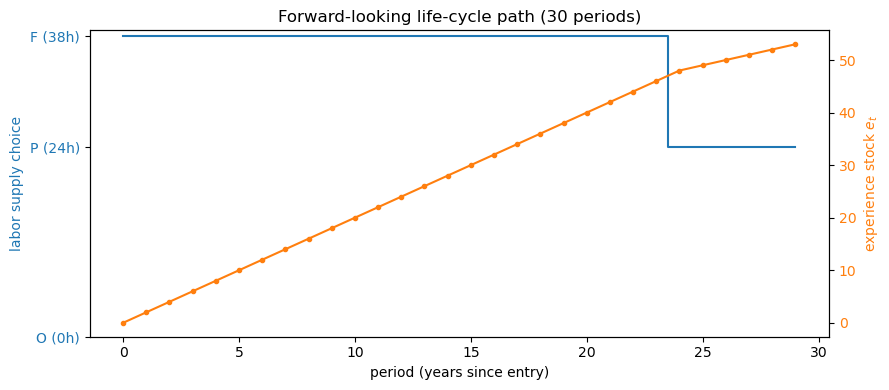

In [24]:
# Visualize the 30-period forward-looking path: choice and experience over time.
# The worker front-loads full-time (costly experience investment), then eases to part-time near the end of the horizon as the shrinking continuation value no longer justifies the extra full-time disutility. This plot also doubles as a sanity check that the 30-period scaling ran a *forward-looking* agent.


hours_to_label = {0: "O", 24: "P", 38: "F"}
periods = df_sim_30.index.to_numpy()
hours = df_sim_30["choice"].to_numpy().astype(int)
exp = df_sim_30["exp_level"].to_numpy().astype(int)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.step(periods, hours, where="mid", color="tab:blue", label="hours choice")
ax1.set_yticks([0, 24, 38])
ax1.set_yticklabels(["O (0h)", "P (24h)", "F (38h)"])
ax1.set_xlabel("period (years since entry)")
ax1.set_ylabel("labor supply choice", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(periods, exp, color="tab:orange", marker=".", label="experience")
ax2.set_ylabel("experience stock $e_t$", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Forward-looking life-cycle path (30 periods)")
fig.tight_layout()
plt.show()


## Problem 6: Extensions of the framework


**6.1 Individual heterogeneity** Discuss how one could introduce relevant individual observed and unobserved heterogeneity into this simple framework. Discuss one option each. What are the implications for the state-space?

**Solution draft 6.1:**

*Motivation.* In real data we observe different choices among *observationally equivalent* individuals. Enriching the model with observed heterogeneity, unobserved types, and stochastic shocks lets it rationalize this dispersion and be taken to data. Blundell et al. (2016) provide a rich template; below we give **one observed** and **one unobserved** margin, and then trace the consequences for the state space.

**Observed heterogeneity: education.**
Workers with different education levels $s$ face different wage profiles (think of Mincer-type specifications). We let the wage parameters be education-specific and estimate them separately:
$$\ln(w_{t}) = \gamma_{s,0} + \gamma_{s,1}\,\ln(e_{t}+1).$$
If education is itself a relevant adjustment margin, it can be modeled as an endogenous pre-labor-market investment, driven by the same forward-looking human-capital logic as the labor-supply choice. Taken as given (predetermined), $s$ is a *fixed* individual characteristic after labor market entry.

**Unobserved heterogeneity: work-disutility types.**
Suppose there are $K$ latent types $k=1,\dots,K$ that differ in their disutility of work, so the disutility vector is type-specific, $\theta^{k}=(\theta^{k}_{P},\theta^{k}_{F})$ (e.g. a low- vs. high-disutility type). The type-specific $\theta^{k}$ and the population type probabilities $\pi_k=\Pr(\text{type}=k)$ are estimated as structural parameters (subject to a normalization). The type is drawn once at entry and is fixed thereafter, but *unobserved* to the econometrician. Note that the estimation strategy in Blundell et al. (2016), using simulated method of moments, differs from the mixture-representation and maximum likelihood procedures discussed in the first problem set.

*(A stochastic wage process like e.g the persistent AR(1) productivity component in the paper is another potential extension, often introduce to accurately capture persistence in wage innovations. It, however, is the subject of Problems 6.2 and 6.1's note below.)*

**Implications for the state space.**
- *Fixed characteristics (education $s$, latent type $k$).* These do not evolve, so they do not enlarge the *per-individual* recursion; they index it. In practice one solves the model **separately for each $(s,k)$ cell**, i.e. the state space is replicated once per cell. Total computational cost scales with the number of cells, $\#s \times K$.
- *Persistent stochastic components.* If instead one adds a serially-correlated shock (an AR(1) productivity term), the *lagged* shock becomes a continuous state variable that must be carried into the continuation value and discretized, inflating the state-space.
- *Curse of dimensionality.* Each added state dimension multiplies the number of states; even a few can make full backward induction intractable. The Keane & Wolpin (1994) lecture covered remedies: e.g. a coarser experience grid with interpolation across grid points, and simulation/approximation of the $\max$ over choices (regression-based interpolation of $E\max$).

**6.2 Introduction of stochastic elements**: Suppose we introduce a stochastic element into wage process $ln(w_{t}) = \gamma_0 + \gamma_1 ln(e_{t} + 1) + \varepsilon_t$. Where $\varepsilon$, the stochastic fluctuations of wages, is assumed to be i.i.d. normally distributed with mean zero, $\varepsilon_t \sim N(0, \sigma_\varepsilon^2)$. As in Problem 4.1 write down the Bellman equation for the value function and describe what changes compared to the deterministic setting. What do we need to assume about the *timing* of the shock, i.e. whether $\varepsilon_t$ is realized before or after the labor-supply choice $l_t$ is made? Assume the shock is observed by the agent and realized before making the labor supply choice. Write down the Bellman equation. Is the shock a state variable? Does it enter the state-space container required to solve the model?

**Solution draft 6.2:**

The wage now carries an i.i.d. shock, $\ln(w_t)=\gamma_0+\gamma_1\ln(e_t+1)+\varepsilon_t$ with $\varepsilon_t\sim N(0,\sigma_\varepsilon^2)$. Since consumption is $c_t=w_t h_t$, the shock enters flow utility through the wage: we write flow utility as $u(l_t;X_t,\varepsilon_t)$ to make the dependence explicit.

**Why timing matters.**
The key question is whether $\varepsilon_t$ is known *before* or *after* the worker chooses $l_t$:
- **Realized after the choice ("expectational" timing).** The worker chooses $l_t$ knowing only the distribution of $\varepsilon_t$. The shock then affects only *realized* earnings; it does not enter the information set at the decision node, so it is **not** a state variable for the choice. It shows up only inside an expectation. (**not the typical setting**)
- **Realized before the choice (assumed here).** The worker observes $\varepsilon_t$ and *then* chooses $l_t$. Now the current shock is part of the information the decision conditions on, so $\varepsilon_t$ **is** a state variable at $t$ and part of $X_t$.
- Note: for the econometrician it is always unobserved.

We adopt the second convention: **$\varepsilon_t$ observed by the worker, realized before $l_t$**, that is, the worker has information that we do not collect in the data.

**Bellman equation (building on 4.1).**
Augment the state to $X_t=(t,e_t,\varepsilon_t)$. Because $\varepsilon_t$ is already known when the worker chooses, the current period involves no expectation; the expectation appears only in the *continuation* value, taken over next period's shock $\varepsilon_{t+1}$:
\begin{equation*}
    V(X_t,\varepsilon_t) = \max_{ l_t \in L } \biggl\{ \; u(l_t; X_t,\varepsilon_t) \;+\; \beta\, E_{\varepsilon_{t+1}}\!\left[\, V\big(X_{t+1},\varepsilon_{t+1}\mid l_t, X_t\big) \,\right] \; \biggr\},
\end{equation*}
with choice-specific value functions
\begin{equation*}
    V(X_t, \varepsilon_t \mid l_t=l) \equiv u(l; X_t,\varepsilon_t) + \beta\, E_{\varepsilon_{t+1}}\!\big[\, V(X_{t+1},\varepsilon_{t+1}\mid l, X_t) \,\big].
\end{equation*}
Here $e_{t+1}=e_t+g(l_t)$ is still deterministic; the *only* stochastic transition is $\varepsilon_{t+1}$, which by i.i.d. is drawn independently of $\varepsilon_t$. So, unlike a persistent AR(1) shock, the current $\varepsilon_t$ does **not** forecast $\varepsilon_{t+1}$: it matters for *today's* payoff but carries no information about the future.

**What changes relative to the deterministic setting.**
- The expectation operator can no longer be dropped: the continuation value integrates over $\varepsilon_{t+1}$,
$$E_{\varepsilon_{t+1}}\!\big[V(X_{t+1},\varepsilon_{t+1})\big]=\int V\big(t+1,\,e_t+g(l_t),\,\varepsilon_{t+1}\big)\,\phi(\varepsilon_{t+1};\sigma_\varepsilon^2)\,d\varepsilon_{t+1},$$
which in practice is computed by Gauss–Hermite quadrature or Monte-Carlo draws over the normal density $\phi$.
- Because the continuation term is an expectation over $\varepsilon_{t+1}$ *before* it is realized, and $\varepsilon_{t+1}$ is i.i.d., this expected continuation value is **the same for all current $\varepsilon_t$** — it depends only on $(t,e_t,l_t)$. The current shock $\varepsilon_t$ therefore shifts only the flow payoff $u(l_t;X_t,\varepsilon_t)$, not the continuation value.

**Is $\varepsilon_t$ a state variable? Does it enter the solution container?**
- **State variable: yes.** Under before-choice timing the worker conditions on $\varepsilon_t$, so it is part of $X_t$ and the optimal choice is a function of it, $l_t^{*}(t,e_t,\varepsilon_t)$.
- **Solution container: no (for an i.i.d. shock).** The discrete `(period, experience)` container built by `create_state_space` need **not** be expanded to a grid over $\varepsilon$. Because the shock is i.i.d., the object we precompute and store by backward induction is the *expected* (integrated) continuation value $\bar V(t,e_t)\equiv E_{\varepsilon}[V(t,e_t,\varepsilon)]$, which lives on exactly the existing `(period, experience)` grid. Concretely, backward induction stores $\bar V(t,e)$; at any state we then integrate the flow payoff over $\varepsilon_t$,
$$\bar V(t,e)=E_{\varepsilon_t}\!\Big[\max_{l\in L}\big\{\,u(l;t,e,\varepsilon_t)+\beta\,\bar V(t{+}1,\,e+g(l))\,\big\}\Big],$$
and simulation draws a fresh $\varepsilon_t$ each period to determine the realized choice. So the shock enters the *utility evaluation and the expectation*, but not the stored state grid.

  *NOTE: $E\max$, not $\max E$.* The $\max$ sits **inside** the expectation because the agent optimizes **after** observing $\varepsilon_t$: for each realized shock the worker picks the best alternative, and we then average the resulting optimized payoff over the shock distribution. Reversing the order ($\max_l E_\varepsilon[\cdot]$) would describe an agent who must commit to a single alternative before seeing the shock. This is the object Keane & Wolpin approximate (the "$E\max$" function).

  *Stored object vs. simulated choice.* Note the division of labor: backward induction **stores** the integrated value $\bar V(t,e)$ on the coarse `(period, experience)` grid, but **simulation** draws a concrete $\varepsilon_t$ each period and takes the realized $\arg\max_l\{u(l;t,e,\varepsilon_t)+\beta\bar V(t{+}1,e+g(l))\}$. So $\varepsilon$ never enters the stored container, yet the simulated choice path is still shock-specific.

- **Persistent shocks as a contrast:** Had the shock been serially correlated (e.g. AR(1), as in 6.1), $\varepsilon_t$ *would* forecast $\varepsilon_{t+1}$; the integrated continuation value would depend on $\varepsilon_t$, and the lagged shock would have to be added as a discretized continuous dimension of the state-space container (curse of dimensionality noted in 6.1).